In [1]:
import pandas as pd
import numpy as np
merchants_df = pd.read_excel('dataset/dstakehome_merchants.xlsx')
payments_df = pd.read_excel('dataset/dstakehome_payments.xlsx')


In [2]:
#['date', 'merchant', 'subscription_volume', 'checkout_volume', 'payment_link_volume', 'total_volume']
payment_columns = payments_df.columns.tolist() 
# ['merchant', 'industry', 'first_charge_date', 'country', 'business_size']
merchant_columns = merchants_df.columns.tolist()


payments_df['merchant'] = payments_df['merchant'].astype(str)
merchants_df['merchant'] = merchants_df['merchant'].astype(str)

In [3]:
    # ???
merchants_df[merchants_df['merchant'] == '0']


,merchant,industry,first_charge_date,country,business_size
11282,0,Healthcare,2040-12-08 00:00:00+00:00,US,small
11606,0,Merchandise,2038-11-30 00:00:00+00:00,CA,small
13020,0,Education,2041-07-15 00:00:00+00:00,MX,small
13384,0,Others,2041-07-24 00:00:00+00:00,GB,small
18458,0,Business services,2041-12-16 00:00:00+00:00,US,small
20739,0,Others,2042-03-10 00:00:00+00:00,US,small
21151,0,Others,2042-03-26 00:00:00+00:00,GB,small
22686,0,Leisure,2042-05-22 00:00:00+00:00,SG,small


# Cleaning stage

In [4]:
def unify_test_dates(df, date_col='date'):

    from dateutil import parser

    def parse_date(val):
        # Try several custom parsing rules
        if pd.isnull(val):
            return pd.NaT
        try:
            # Try ISO 8601 with optional 'T' and 'Z', e.g., 2042-06-22T00:00:00Z
            return pd.to_datetime(val, format="%Y-%m-%dT%H:%M:%SZ", errors='raise', utc=True)
        except Exception:
            pass
        try:
            # Try classic ISO format first
            return pd.to_datetime(val, format="%Y-%m-%d", errors='raise')
        except Exception:
            pass
        try:
            # Try common "day-mon-year" format
            return pd.to_datetime(val, format="%d-%b-%y", errors='raise')
        except Exception:
            pass
        try:
            # Try "day-mon-year hour:min:sec"
            return pd.to_datetime(val, format="%d-%b-%y %H:%M:%S", errors='raise')
        except Exception:
            pass
        try:
            # Use dateutil parser as a fallback (very permissive)
            return parser.parse(str(val), dayfirst=True, fuzzy=True)
        except Exception:
            return pd.NaT

    df[date_col] = df[date_col].apply(parse_date)
    return df

payments_df_clean = unify_test_dates(payments_df, 'date')
merchants_df_clean = unify_test_dates(merchants_df, 'first_charge_date')


In [5]:
total_df = payments_df_clean.copy()
total_df = total_df.merge(merchants_df_clean, on='merchant', how='left')
total_df.drop(['first_charge_date', 'country'], axis=1, inplace=True)
total_df = total_df[total_df['merchant'] != '0']

In [6]:
# Calculate the subscription ratio for each merchant (total_subscription_volume / total_volume)
subscription_ratio_df = (
    total_df.groupby("merchant")[["subscription_volume", "total_volume"]]
    .sum()
    .assign(
        subscription_ratio=lambda df: df["subscription_volume"] / df["total_volume"].replace(0, np.nan)
    )
    .sort_values("subscription_ratio", ascending=False)
)
cv_df = (
    total_df.groupby("merchant")[["total_volume"]]
    .agg(['mean', 'std'])
)
cv_df.columns = ['mean_total_volume', 'std_total_volume']
cv_df['cv_total_volume'] = cv_df['std_total_volume'] / cv_df['mean_total_volume'].replace(0, np.nan)
cv_df = cv_df.sort_values("cv_total_volume", ascending=False)

subscription_ratio_df.rename(columns={'subscription_volume': 'sub_cap', 'total_volume': 'total_cap'}, inplace=True)
subscription_ratio_df.reset_index(inplace=True)

total_df = total_df.merge(subscription_ratio_df, on='merchant', how='left')
total_df = total_df.merge(cv_df, on='merchant', how='left')


In [7]:
sub_merchants = total_df[total_df['subscription_ratio'] > 0.8]['merchant'].unique()
total_merchants = total_df['merchant'].unique()
print("merchants who the subscription ratio is greater than 0.8: ",len(sub_merchants) / len(total_merchants))





merchants who the subscription ratio is greater than 0.8:  0.10533892205427833


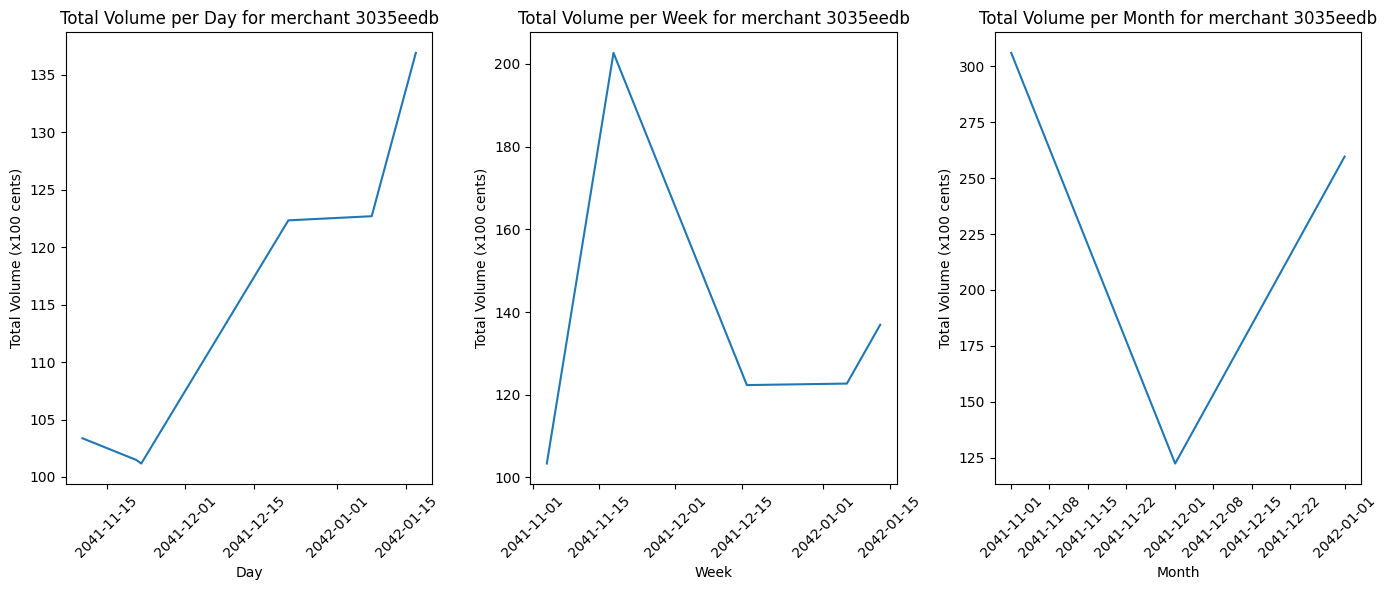

In [8]:
import matplotlib.pyplot as plt
import warnings
merchant_id = '3035eedb'
store_df = total_df[total_df['merchant'] == merchant_id].copy()
store_df = store_df.sort_values('date')
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UserWarning)
    store_df['week'] = store_df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    store_df['day'] = store_df['date'].dt.to_period('D').apply(lambda r: r.start_time)
    store_df['month'] = store_df['date'].dt.to_period('M').apply(lambda r: r.start_time)

fig, axs = plt.subplots(1, 3, figsize=(14, 6), sharex=False)

# Day plot
axs[0].plot(store_df.groupby('day')['total_volume'].sum() / 100)
axs[0].set_xlabel("Day")
axs[0].set_ylabel("Total Volume (x100 cents)")
axs[0].set_title(f"Total Volume per Day for merchant {merchant_id}")
axs[0].tick_params(axis='x', rotation=45)

# Week plot
axs[1].plot(store_df.groupby('week')['total_volume'].sum() / 100)
axs[1].set_xlabel("Week")
axs[1].set_ylabel("Total Volume (x100 cents)")
axs[1].set_title(f"Total Volume per Week for merchant {merchant_id}")
axs[1].tick_params(axis='x', rotation=45)

# Month plot
axs[2].plot(store_df.groupby('month')['total_volume'].sum() / 100)
axs[2].set_xlabel("Month")
axs[2].set_ylabel("Total Volume (x100 cents)")
axs[2].set_title(f"Total Volume per Month for merchant {merchant_id}")
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

0480e56c


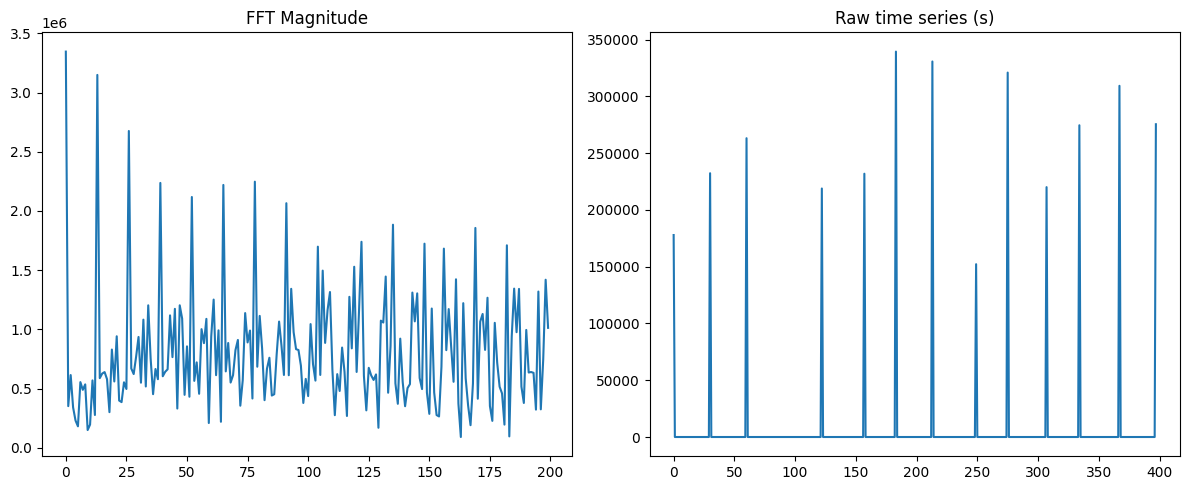

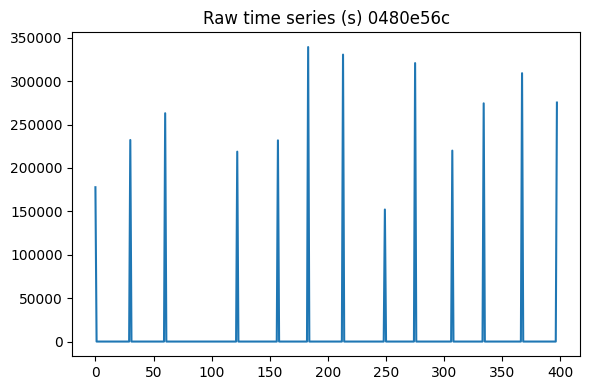

active_ratio                         0.035176
weekly_autocorr                      -0.03022
biweekly_autocorr                   -0.030788
monthly_autocorr                     0.332621
avg_gap_between_payments            30.538462
gap_regularity_share_7d                   0.0
gap_regularity_share_30d             0.307692
gaps_std                            10.463235
weekday_entropy                      1.846889
cv_volume                            5.581317
cv_weekly                            0.371552
cv_monthly                           0.227155
burstiness                          -0.458202
industry_boost                            1.0
volume_scale                         8.155679
total_volume                          3346130
subscription_ratio                        0.0
checkout_ratio                            0.0
payment_link_ratio                        0.0
business_size                           small
industry                    Business services
dtype: object

In [118]:


def clamp01(x: float) -> float:
    if pd.isna(x):
        return 0.0
    return float(max(0.0, min(1.0, x)))

def coef_var(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    if len(x) == 1:
        # Warn or quietly return np.nan if only 1 value (prevents degrees of freedom <= 0)
        return np.nan
    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=1))  # Use unbiased estimator (N-1); avoid ddof=0 warning if only one value
    if np.isclose(mu, 0):
        # Prevent divide by zero, emit a clearer NaN
        return np.nan
    return float(sd / mu)

def gap_regularity_share(days: pd.Series, target_gap: int, tol: int = 1) -> float:
    """Share of inter-payment gaps close to a target cadence (e.g. 7 or 30 days)."""
    if len(days) < 6:
        return np.nan
    d = pd.to_datetime(days).sort_values().dropna()
    gaps = d.diff().dt.days.dropna().to_numpy()
    if len(gaps) == 0:
        return np.nan
    return float(np.mean(np.abs(gaps - target_gap) <= tol))

def merchant_recurring_features(group, date_col='date', value_col='total_volume', verbose=False):
    # 1. Sort and prepare
    group = group.sort_values(date_col).copy()
    group[date_col] = pd.to_datetime(group[date_col])
    group = group.set_index(date_col)
    # 2. Create consecutive daily time series
    s = group[value_col].asfreq('D', fill_value=0)
    # 3. Basic signals
    total_days = len(s)
    active_days = (s > 0).sum()
    active_ratio = active_days / total_days if total_days > 0 else np.nan

    # 4. Autocorrelation (weekly + monthly patterns)
    def safe_autocorr(series, lag):
        if len(series) <= lag or series.nunique() <= 1:
            return np.nan
        return series.autocorr(lag=lag)

    weekly_autocorr = safe_autocorr(s, lag=7)
    biweekly_autocorr = safe_autocorr(s, lag=14)
    monthly_autocorr = safe_autocorr(s, lag=30)

    # 5. Occurrence pattern (how often payments happen)
    avg_gap = np.nan
    payment_days = s[s > 0].index
    gaps_std = np.nan
    if len(payment_days) > 1:
        gaps = np.diff(payment_days.values).astype('timedelta64[D]').astype(int)
        if len(gaps) > 0:
            avg_gap = gaps.mean()
        else:
            avg_gap = np.nan
        gaps_std = np.std(gaps) if len(gaps) > 1 else np.nan


    mean_val = s.mean()
    std_val = s.std(ddof=1) if len(s) > 1 else np.nan  # ddof=1 for unbiased; nan for single value

    # Prevent divide by zero (and thus suppress RuntimeWarning)
    if np.isclose(mean_val, 0):
        cv = np.nan
    else:
        cv = std_val / mean_val  # coefficient of variation

    total_volume_sum = group['total_volume'].sum()
    subscription_volume_sum = group['subscription_volume'].sum()
    checkout_volume_sum = group['checkout_volume'].sum()
    payment_link_volume_sum = group['payment_link_volume'].sum()

    # Prevent division by zero by checking if total_volume_sum is "close to zero"
    if np.isclose(total_volume_sum, 0):
        subscription_ratio = np.nan
        checkout_ratio = np.nan
        payment_link_ratio = np.nan
    else:
        subscription_ratio = subscription_volume_sum / total_volume_sum
        checkout_ratio = checkout_volume_sum / total_volume_sum
        payment_link_ratio = payment_link_volume_sum / total_volume_sum

    weekly_totals = group['total_volume'].resample('W').sum().to_numpy(dtype=float)
    # Suppress warning by checking length
    # Also prevent divide by zero inside coef_var
    nonzero_weekly = weekly_totals[~np.isclose(weekly_totals, 0)]
    if len(nonzero_weekly) > 1:
        weekly_cv = coef_var(nonzero_weekly)
    else:
        weekly_cv = np.nan

    monthly_totals = group['total_volume'].resample('ME').sum().to_numpy(dtype=float)
    nonzero_monthly = monthly_totals[~np.isclose(monthly_totals, 0)]
    if len(nonzero_monthly) > 1:
        monthly_cv = coef_var(nonzero_monthly)
    else:
        monthly_cv = np.nan

    industry = str(group['industry'].iloc[0]).lower()

    if industry:
        if any(k in industry for k in ['software', 'education', 'membership', 'religion', 'fitness', 'health', 'business services', 'leisure']):
            industry_boost = 1.0
        elif any(k in industry for k in ['retail', 'restaurant', 'food', 'travel', 'events']):
            industry_boost = 0.3
        else:
            industry_boost = 0.0
    else:
        industry_boost = 0.0  # ensure defined

    # Size sanity: avoid tiny merchants dominating by perfect regularity
    tot = total_volume_sum
    # Prevent log of zero/negative. (1+tot) always nonzero/positive as tot>=0
    size = clamp01(np.log10(1 + tot) / np.log10(1 + 10e7))  # 10e6 cents = $1M
    # print(np.log10(1 + tot) / np.log10(1 + 10e6))
    volume_scale = 10 * size

    # entropy of weekday distribution
    weekday_counts = s[s > 0].index.weekday
    weekday_entropy = -np.sum(np.bincount(weekday_counts, minlength=7) / len(weekday_counts)
    * np.log(np.bincount(weekday_counts, minlength=7) / len(weekday_counts) + 1e-9))

    nonzero_days = s[s > 0]
    if len(nonzero_days) > 1:
        burstiness = (nonzero_days.std() - nonzero_days.mean()) / (nonzero_days.std() + nonzero_days.mean())
    else:
        burstiness = np.nan

    if verbose:
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        axs[0].plot(np.abs(np.fft.rfft(s)))
        axs[0].set_title("FFT Magnitude")
        axs[1].plot(s.values)
        axs[1].set_title("Raw time series (s)")
        plt.tight_layout()
        plt.show()

    if verbose:
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 1, figsize=(6, 4))
        axs.plot(s.values)
        axs.set_title(f"Raw time series (s) {merchant_id}")
        plt.tight_layout()
        plt.savefig(f"raw_time_series_{merchant_id}.pdf")
        plt.show()

    return pd.Series({
        'active_ratio': active_ratio,
        'weekly_autocorr': weekly_autocorr,
        'biweekly_autocorr': biweekly_autocorr,
        'monthly_autocorr': monthly_autocorr,
        'avg_gap_between_payments': avg_gap,
        'gap_regularity_share_7d': gap_regularity_share(group.reset_index()['date'], 7),
        'gap_regularity_share_30d': gap_regularity_share(group.reset_index()['date'], 30),
        'gaps_std': gaps_std,
        'weekday_entropy': weekday_entropy,
        'cv_volume': cv,
        'cv_weekly': weekly_cv,
        'cv_monthly': monthly_cv,
        'burstiness': burstiness,
        'industry_boost': industry_boost,
        'volume_scale': volume_scale,
        'total_volume': total_volume_sum,
        'subscription_ratio': subscription_ratio,
        'checkout_ratio': checkout_ratio,
        'payment_link_ratio': payment_link_ratio,
        'business_size': group['business_size'].iloc[0],
        'industry': group['industry'].iloc[0]
    })

for merchant_id, group in total_df.groupby('merchant'):
    if merchant_id == '0480e56c':
        print(merchant_id)
        a = merchant_recurring_features(group, value_col='total_volume', verbose=True)
        display(a)
        break

In [11]:
# Extract features for each merchant and construct a DataFrame with merchants as rows and features as columns
feature_extracted_list = []
merchant_ids = []
for merchant_id, group in total_df.groupby('merchant'):
    # print(merchant_id)
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        features = merchant_recurring_features(group, value_col='total_volume')
        feature_extracted_list.append(features)
        merchant_ids.append(merchant_id)

feature_extracted = pd.DataFrame(feature_extracted_list, index=merchant_ids)

In [12]:
feature_extracted.fillna(0, inplace=True)
# high subscription merchants records
# after computing all merchant features

good = feature_extracted[feature_extracted['subscription_ratio'] > 0.9]

centroid = good.mean(numeric_only=True)

from sklearn.metrics.pairwise import cosine_similarity

X = feature_extracted.select_dtypes(include=[np.number]).fillna(0)

feature_extracted['similarity_to_good'] = cosine_similarity(
    X, centroid.values.reshape(1, -1)
).flatten()

# COSINE based annotating 

In [15]:

from sklearn.metrics.pairwise import cosine_similarity
sub_features = feature_extracted[feature_extracted['subscription_ratio'] > 0.9]
non_sub_features = feature_extracted[feature_extracted['subscription_ratio'] < 0.2]


# Choose feature columns to use for similarity (exclude business_size, industry, and possibly any other categorical)
exclude_cols = ['business_size', 'industry']
feature_cols = [col for col in sub_features.columns if col not in exclude_cols]

sub_vecs = sub_features[feature_cols].values
sub_vecs = np.nan_to_num(sub_vecs, nan=0)

non_sub_vecs = non_sub_features[feature_cols].values
non_sub_vecs = np.nan_to_num(non_sub_vecs, nan=0)

# Compute similarity of each non_subscription merchant to the average feature vector of sub_features
sub_mean_vec = sub_vecs.mean(axis=0, keepdims=True)
cos_sim = cosine_similarity(non_sub_vecs, sub_mean_vec).flatten()

# Attach similarity scores back to the non_sub_features DataFrame
non_sub_features_sim = non_sub_features.copy()
non_sub_features_sim['sim_to_sub'] = cos_sim

# Find top candidates
top_candidates = non_sub_features_sim.sort_values('sim_to_sub', ascending=False).head(10)
top_candidates

,active_ratio,weekly_autocorr,biweekly_autocorr,monthly_autocorr,avg_gap_between_payments,gap_regularity_share_7d,gap_regularity_share_30d,gaps_std,weekday_entropy,cv_volume,...,industry_boost,volume_scale,total_volume,subscription_ratio,checkout_ratio,payment_link_ratio,business_size,industry,similarity_to_good,sim_to_sub
9a06d9c2,0.039216,-0.030198,0.090230,-0.030722,27.133333,0.066667,0.066667,16.732669,1.494175,5.681113,...,1.0,9.226168,24040000,0.000000,0.0,0.00000,small,Software,1.0,1.0
e76ffd89,0.070707,-0.025396,0.122937,-0.034324,15.153846,0.000000,0.000000,9.686201,1.296361,5.396529,...,0.0,8.907884,13375415,0.000000,0.0,1.00000,small,Construction,1.0,1.0
34288d6d,0.051020,-0.003223,-0.041076,-0.013307,20.578947,0.157895,0.052632,14.726688,1.544480,4.931260,...,0.3,9.047753,17306225,0.000000,0.0,0.00000,medium,Grocery & food stores,1.0,1.0
f1f9a7d3,0.046448,0.056923,-0.035768,0.074664,22.812500,0.250000,0.250000,9.773809,1.641845,5.777314,...,1.0,8.972342,15061697,0.000000,0.0,0.00000,small,Business services,1.0,1.0
fcb72eec,0.067647,-0.036047,0.080814,0.090786,15.409091,0.045455,0.045455,10.298540,1.376090,4.196009,...,1.0,8.867425,12414800,0.000000,0.0,0.00000,small,Business services,1.0,1.0
11cdde01,0.100000,0.046463,-0.076391,0.015049,10.692308,0.384615,0.000000,4.873549,1.400327,3.525461,...,0.3,8.724306,9537726,0.000000,0.0,0.00000,small,Grocery & food stores,1.0,1.0
4b4cfdb7,0.085000,-0.062727,-0.047214,0.231000,12.090909,0.030303,0.030303,8.589506,1.764877,3.990305,...,1.0,8.993663,15665000,0.006384,0.0,0.00000,small,Business services,1.0,1.0
fbc7ee45,0.061069,0.030671,-0.036752,-0.021231,17.043478,0.217391,0.000000,13.297526,1.592657,5.003490,...,1.0,8.952347,14517018,0.000000,0.0,0.00000,small,Business services,1.0,1.0
6ffe668f,0.022222,-0.009435,-0.009986,-0.011526,67.000000,0.000000,0.000000,10.000000,0.636514,9.725227,...,1.0,9.569891,45280699,0.000000,0.0,0.17784,small,Business services,1.0,1.0
71266d1c,0.096203,-0.031491,0.112018,0.095097,10.648649,0.162162,0.027027,7.159255,1.484566,3.219081,...,1.0,8.949835,14450006,0.000000,0.0,0.00000,small,Business services,1.0,1.0


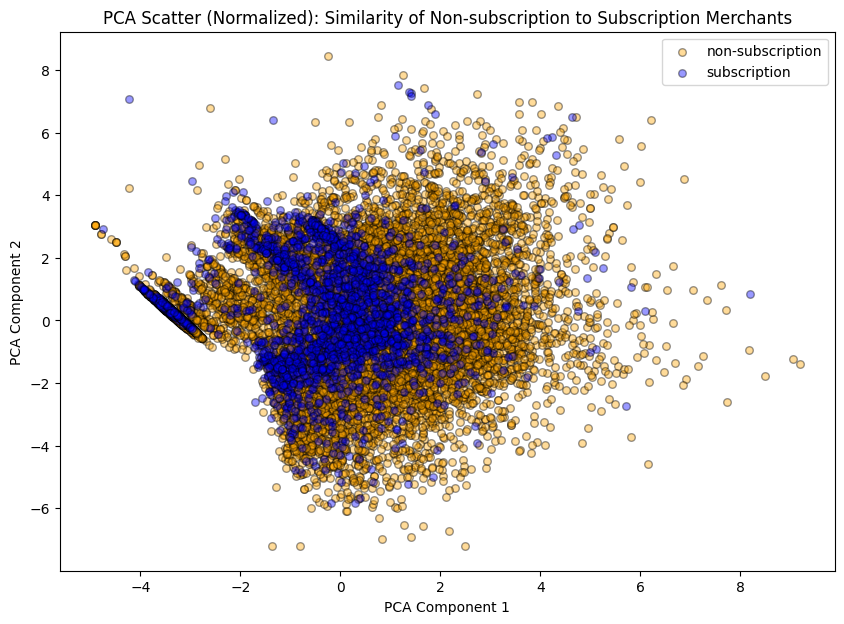

/Users/alirezakeshavarzian/ThesisProject/STRIP/myenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/alirezakeshavarzian/ThesisProject/STRIP/myenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,active_ratio,weekly_autocorr,biweekly_autocorr,monthly_autocorr,avg_gap_between_payments,gap_regularity_share_7d,gap_regularity_share_30d,gaps_std,weekday_entropy,cv_volume,...,industry_boost,volume_scale,total_volume,subscription_ratio,checkout_ratio,payment_link_ratio,business_size,industry,similarity_to_good,sim_to_sub
ef4a148a,0.049869,-0.031742,-0.028494,0.326066,21.111111,0.055556,0.444444,10.999439,1.885764,5.371451,...,1.0,6.568520,179810,0.154919,0.0,0.045520,small,Business services,1.000000,0.404423
4ea53f24,0.065491,0.000537,-0.020554,0.082293,15.840000,0.160000,0.120000,11.948824,1.925121,4.157971,...,1.0,7.717488,1492760,0.190185,0.0,0.028806,small,Business services,1.000000,0.388116
eb69b5c5,0.038043,-0.035088,-0.036585,0.479730,30.500000,0.000000,1.000000,0.500000,1.747868,5.042211,...,1.0,4.775744,6615,0.000000,0.0,0.000000,small,Business services,0.999989,0.374284
800fad0d,0.042254,-0.036450,-0.036804,0.757044,26.500000,0.000000,0.625000,6.800735,1.522955,5.003208,...,1.0,7.495836,992358,0.000000,0.0,0.000000,small,Software,1.000000,0.371782
ba503321,0.032911,-0.031670,-0.032270,0.309634,32.833333,0.000000,0.500000,6.792561,1.844621,5.466930,...,1.0,6.184323,88604,0.000000,0.0,0.000000,small,Education,1.000000,0.369410
47853c4b,0.038961,-0.035211,-0.037037,0.374790,30.600000,0.000000,1.000000,0.489898,1.791759,4.982759,...,1.0,5.967242,59400,0.000000,0.0,0.000000,small,Business services,1.000000,0.365965
ea15635a,0.039106,-0.038431,-0.039243,0.288480,27.461538,0.000000,0.538462,4.970921,1.710493,4.966401,...,1.0,7.403176,836643,0.000000,0.0,0.000000,small,Software,1.000000,0.363985
c85d52c1,0.036066,-0.034722,-0.035587,0.291811,30.400000,0.000000,0.900000,0.916515,1.846220,5.178339,...,1.0,5.427782,21989,0.000000,0.0,0.000000,small,Business services,0.999999,0.362050
aecc0ac2,0.035264,-0.034483,-0.035135,0.282269,30.461538,0.000000,0.923077,0.842650,1.871160,5.237005,...,1.0,5.680101,35000,0.000000,0.0,0.000000,small,Education,1.000000,0.360029
288447d7,0.046512,-0.042184,-0.043118,0.253245,22.866667,0.000000,0.333333,16.922831,1.786808,4.786297,...,1.0,6.839399,296154,0.048019,0.0,0.048019,small,Software,1.000000,0.358095


In [16]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select sub and non-subscription merchant groups
sub_features = feature_extracted[feature_extracted['subscription_ratio'] > 0.9]
non_sub_features = feature_extracted[feature_extracted['subscription_ratio'] < 0.2]

# Exclude categorical columns for similarity and PCA embedding
exclude_cols = ['business_size', 'industry']
feature_cols = [col for col in sub_features.columns if col not in exclude_cols]

# Prepare DataFrames for normalization and visualization
sub_plot = sub_features[feature_cols].copy()
sub_plot['type'] = 'subscription'
non_sub_plot = non_sub_features[feature_cols].copy()
non_sub_plot['type'] = 'non-subscription'
plot_df = pd.concat([sub_plot, non_sub_plot])

# Normalize feature columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(plot_df[feature_cols])

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA results to dataframe
plot_df['PCA1'] = X_pca[:, 0]
plot_df['PCA2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(10, 7))
colors = {'non-subscription': 'orange', 'subscription': 'blue'}
for label, color in colors.items():
    plt.scatter(
        plot_df.loc[plot_df['type'] == label, 'PCA1'], 
        plot_df.loc[plot_df['type'] == label, 'PCA2'],
        label=label,
        alpha=0.4,
        c=color,
        edgecolor="k",
        s=30
    )
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Scatter (Normalized): Similarity of Non-subscription to Subscription Merchants')
plt.legend()
plt.show()

# Additionally, still return the DataFrame of closest non-subs to sub-mean (optional)
from sklearn.metrics.pairwise import cosine_similarity

sub_vecs = scaler.transform(sub_features[feature_cols].values)
non_sub_vecs = scaler.transform(non_sub_features[feature_cols].values)

sub_mean_vec = sub_vecs.mean(axis=0, keepdims=True)
cos_sim = cosine_similarity(non_sub_vecs, sub_mean_vec).flatten()
non_sub_features_sim = non_sub_features.copy()
non_sub_features_sim['sim_to_sub'] = cos_sim

top_candidates = non_sub_features_sim.sort_values('sim_to_sub', ascending=False).head(10)
top_candidates

In [17]:
lowest_date = total_df['date'].min()
highest_date = total_df['date'].max()
print("Lowest date:", lowest_date)
print("Highest date:", highest_date)

import pandas as pd

# Create a full daily date range from lowest to highest date
full_range = pd.date_range(start=lowest_date, end=highest_date, freq='D')

# Get unique merchant IDs
merchant_ids = total_df['merchant'].unique()

# Build a MultiIndex DataFrame for all dates x merchants
full_index = pd.MultiIndex.from_product([full_range, merchant_ids], names=['date', 'merchant'])
full_ts_df = pd.DataFrame(index=full_index).reset_index()

# Merge with your total_df to bring in the actual records
# Assume you want to fill with zeros where data is missing for all columns except 'date' and 'merchant'
merged = pd.merge(
    full_ts_df,
    total_df,
    how='left',
    on=['date', 'merchant']
)

# Fill potentially multiple numeric columns with 0 where missing, leaving object/categorical columns untouched if desired
numeric_cols = merged.select_dtypes(include=['number']).columns.tolist()
# Don't fill 'merchant' and 'date', those are not null
numeric_cols = [col for col in numeric_cols if col not in ['merchant']]

merged[numeric_cols] = merged[numeric_cols].fillna(0)

# If you want to drop any columns filled with all NaNs, or specify fill for other columns, you can do so here.
# The resulting DataFrame `merged` is a time series of merchants by day, with missing intervals filled as zeros

Lowest date: 2041-05-01 00:00:00+00:00
Highest date: 2042-06-22 00:00:00+00:00


In [18]:

time_series_output = []
merchant_id_list = []
def time_series_df(group,min_date,max_date, date_col='date', value_col='total_volume'):
    group = group.sort_values(date_col).copy()
    group[date_col] = pd.to_datetime(group[date_col])
    group = group.set_index(date_col)
    # 2. Create consecutive daily time series
    full_range = pd.date_range(start=min_date, end=max_date, freq='D')
    s = group.reindex(full_range)[value_col].fillna(0)
    s.index = full_range
    # INSERT_YOUR_CODE
    s_min = s.min()
    s_max = s.max()
    if s_max > s_min:
        s = (s - s_min) / (s_max - s_min)
    else:
        s = s * 0  # if all values are the same, set to 0
    return s.tolist()


min_date = total_df['date'].min()
max_date = total_df['date'].max()
for merchant_id, group in total_df.groupby('merchant'):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        ts = time_series_df(group,min_date,max_date)
        time_series_output.append(ts)
        merchant_id_list.append(merchant_id)
time_series_output = np.array(time_series_output)


In [19]:
import rocket.miniROCKET as mr
from sklearn.preprocessing import StandardScaler

time_series_output = time_series_output.astype(np.float32)
parameter = mr.fit(time_series_output,num_features=10000)
dilations, num_features_per_dilation,_, biases = parameter
parameter = dilations, num_features_per_dilation,biases

time_series_tranformed = mr.transform(time_series_output, parameter,'ter')


scaler = StandardScaler()
time_series_transformed_scaled = scaler.fit_transform(time_series_tranformed)

In [20]:
excludede_columns = ['subscription_ratio','business_size', 'industry']
feature_extracted.loc['000a45ba'].drop(excludede_columns).values.tolist()

[np.float64(0.09610389610389611),
 np.float64(0.07858257025690377),
 np.float64(0.10293650813548905),
 np.float64(-0.04889686493018572),
 np.float64(10.666666666666666),
 np.float64(0.1388888888888889),
 np.float64(0.027777777777777776),
 np.float64(15.249772311597164),
 np.float64(1.832904240141466),
 np.float64(3.626897965261155),
 np.float64(0.9743525444552535),
 np.float64(1.0588833193180909),
 np.float64(-0.24552892754978847),
 np.float64(0.0),
 np.float64(6.442272386520708),
 np.int64(142500),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.9999999901502687)]

In [21]:
feature_extracted

,active_ratio,weekly_autocorr,biweekly_autocorr,monthly_autocorr,avg_gap_between_payments,gap_regularity_share_7d,gap_regularity_share_30d,gaps_std,weekday_entropy,cv_volume,...,burstiness,industry_boost,volume_scale,total_volume,subscription_ratio,checkout_ratio,payment_link_ratio,business_size,industry,similarity_to_good
00085cb5,0.119701,0.016226,0.059676,0.063177,8.510638,0.276596,0.021277,8.204494,1.787475e+00,4.596632,...,0.128610,1.0,8.390812,5160000,0.000000,1.000000,0.0,small,Software,1.000000
000a45ba,0.096104,0.078583,0.102937,-0.048897,10.666667,0.138889,0.027778,15.249772,1.832904e+00,3.626898,...,-0.245529,0.0,6.442272,142500,0.649123,0.000000,0.0,small,Others,1.000000
000e2c0e,0.186701,-0.046456,-0.036780,0.353476,5.416667,0.152778,0.000000,5.248677,1.877183e+00,3.169308,...,0.017358,1.0,7.492901,987007,0.526971,0.000000,0.0,small,Education,1.000000
001111d7,0.150000,0.045717,-0.008033,-0.056203,7.375000,0.125000,0.000000,6.223695,1.676988e+00,5.536621,...,0.340444,0.0,7.838638,1865995,0.000000,0.000000,0.0,small,Transportation & car rental,1.000000
0015c036,0.184282,0.054903,-0.126946,0.236675,5.492537,0.000000,0.000000,4.927453,1.922426e+00,2.243093,...,-0.500858,0.0,5.261927,16200,1.000000,0.851852,0.0,small,Others,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffe98e3f,0.922500,0.631535,0.333477,0.020777,1.084239,0.000000,0.000000,0.613234,1.945719e+00,1.743213,...,0.245599,0.3,9.753752,63533332,0.000000,0.000000,0.0,small,Ticketing & events,1.000000
ffee7774,0.604240,0.062487,-0.014249,0.015532,1.658824,0.017647,0.000000,1.922333,1.937552e+00,1.788702,...,0.107472,1.0,6.451482,144938,0.000000,0.000000,0.0,small,Software,1.000000
fff31b9b,0.135294,0.011524,-0.014541,-0.015966,7.681818,0.090909,0.000000,15.387085,1.839021e+00,8.573953,...,0.508754,0.0,7.738118,1550580,0.000000,0.000000,0.0,small,Clothing & accessory,1.000000
fffe09ec,0.183575,0.178105,0.107737,-0.056026,5.506667,0.040000,0.000000,12.820165,1.860408e+00,3.218002,...,0.022548,0.0,8.069983,2857500,0.150516,0.000000,0.0,small,Personal services,1.000000


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier


good_sub_merchant = feature_extracted[feature_extracted['subscription_ratio'] > 0.7].reset_index().rename(columns={'index':'merchant'})['merchant'].tolist()
good_sub_merchant_indices = [merchant_id_list.index(m) for m in good_sub_merchant if m in merchant_id_list]
# Here's an improved and bug-annotated rewrite:
good_sub_merchant = feature_extracted[feature_extracted['subscription_ratio'] > 0.7].reset_index().rename(columns={'index': 'merchant'})['merchant'].tolist()
unknown_merchant = feature_extracted[feature_extracted['subscription_ratio'] < 0.2].reset_index().rename(columns={'index': 'merchant'})['merchant'].tolist()

np.random.seed(None)
#PCA
n_components = 2
pca = PCA(n_components=n_components)
time_series_pca = pca.fit_transform(time_series_transformed_scaled)
print(f"PCA explained variance ratio (first {n_components}: {pca.explained_variance_ratio_}")

x_subscripted_feature = []
y_subscripted = []
m_subscripted = []

excludede_columns = ['subscription_ratio','business_size', 'industry']

for m in good_sub_merchant:
    # f = feature_extracted.loc[m].values[:12].tolist()
    f = feature_extracted.loc[m].drop(excludede_columns).values.tolist()
    f = np.abs(np.nan_to_num(f, nan=0))
    idx = merchant_id_list.index(m)
    m_subscripted.append(m)
    # x_subscripted_feature.append(np.concatenate([time_series_pca[idx], f]))
    x_subscripted_feature.append(f)
    y_subscripted.append('subscription')

x_unknown_feature = []
y_unknown = []
m_unknown = []
for m in unknown_merchant:
    # f = feature_extracted.loc[m].values[:12].tolist()
    f = feature_extracted.loc[m].drop(excludede_columns).values.tolist()
    f = np.abs(np.nan_to_num(f, nan=0))
    idx = merchant_id_list.index(m)
    m_unknown.append(m)
    # x_unknown_feature.append(np.concatenate([time_series_pca[idx], f]))
    x_unknown_feature.append(f)
    y_unknown.append('non-subscription')

x_subscripted_feature = np.array(x_subscripted_feature)
y_subscripted = np.array(y_subscripted)
m_subscripted = np.array(m_subscripted)

x_unknown_feature = np.array(x_unknown_feature)
y_unknown = np.array(y_unknown)
m_unknown = np.array(m_unknown)

print('===============================================')
print('Total number of subscription merchants: ', x_subscripted_feature.shape)

print('Total number of non-subscription merchants: ', x_unknown_feature.shape)
# dataset creation

indices_sub_train = np.random.choice(range(len(x_subscripted_feature)), size=int(len(x_subscripted_feature)*0.7), replace=False)
indices_sub_test = [i for i in range(len(x_subscripted_feature)) if i not in indices_sub_train]


number_of_non_sub = min(int(len(x_subscripted_feature)*4), len(x_unknown_feature))  # Avoid overflow; don't pick more samples than possible.
indices_non_sub_train = np.random.choice(range(len(x_unknown_feature)),size=int(number_of_non_sub*0.7),replace=False)
rest_of_unknown = set(np.arange(len(x_unknown_feature))) - set(indices_non_sub_train)
# If remaining is not enough, sample with replacement (guards against ValueError)
size_for_non_sub_test = int(number_of_non_sub*0.3)
if len(rest_of_unknown) >= size_for_non_sub_test:
    indices_non_sub_test = np.random.choice(list(rest_of_unknown), size=size_for_non_sub_test, replace=False)
else:
    indices_non_sub_test = np.random.choice(range(len(x_unknown_feature)), size=size_for_non_sub_test, replace=True)

x_train = np.concatenate([x_subscripted_feature[indices_sub_train], x_unknown_feature[indices_non_sub_train]])
y_train = np.concatenate([y_subscripted[indices_sub_train], y_unknown[indices_non_sub_train]])
m_train = np.concatenate([m_subscripted[indices_sub_train], m_unknown[indices_non_sub_train]])

x_test = np.concatenate([x_subscripted_feature[indices_sub_test], x_unknown_feature[indices_non_sub_test]])
y_test = np.concatenate([y_subscripted[indices_sub_test], y_unknown[indices_non_sub_test]])
m_test = np.concatenate([m_subscripted[indices_sub_test], m_unknown[indices_non_sub_test]])


print('X_test shape: ',x_test.shape)
print('X_train shape: ', x_train.shape)
print('y_train shape: ', y_train.shape)
print('X_train shape: ', x_train.shape)
print('y_train shape: ', y_train.shape)
print('X_test shape: ', x_test.shape)
print('y_test shape: ', y_test.shape)

#scaling 
# scaler = StandardScaler()
# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

ridge_classifier = RidgeClassifier(alpha=1, class_weight='balanced')
ridge_classifier.fit(x_train, y_train)


PCA explained variance ratio (first 2: [0.83643544 0.07826684]
Total number of subscription merchants:  (2675, 19)
Total number of non-subscription merchants:  (19979, 19)
X_test shape:  (4013, 19)
X_train shape:  (9361, 19)
y_train shape:  (9361,)
X_train shape:  (9361, 19)
y_train shape:  (9361,)
X_test shape:  (4013, 19)
y_test shape:  (4013,)


/Users/alirezakeshavarzian/ThesisProject/STRIP/myenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=7.69728e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,'balanced'
,solver,'auto'
,positive,False
,random_state,None


Accuracy test:  0.7984051831547471 Accuracy train:  0.7899797030231813


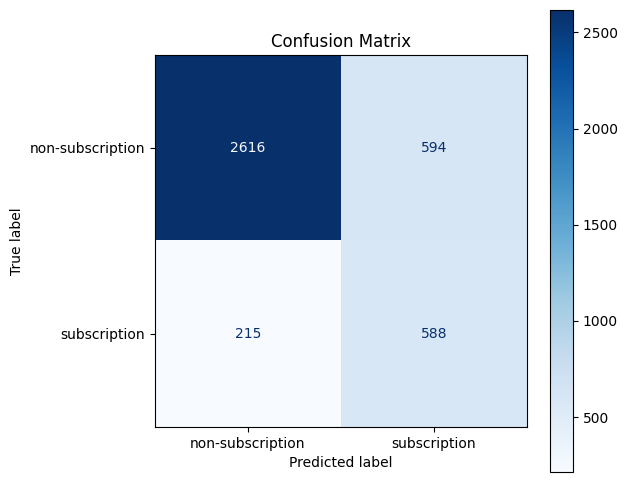

In [24]:
accuracy_test, accuracy_train = ridge_classifier.score(x_test, y_test), ridge_classifier.score(x_train, y_train)
print('Accuracy test: ',accuracy_test, 'Accuracy train: ',accuracy_train)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = ridge_classifier.predict(x_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=ridge_classifier.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
fea

,active_ratio,weekly_autocorr,biweekly_autocorr,monthly_autocorr,avg_gap_between_payments,gap_regularity_share_7d,gap_regularity_share_30d,gaps_std,weekday_entropy,cv_volume,...,burstiness,industry_boost,volume_scale,total_volume,subscription_ratio,checkout_ratio,payment_link_ratio,business_size,industry,similarity_to_good
00085cb5,0.119701,0.016226,0.059676,0.063177,8.510638,0.276596,0.021277,8.204494,1.787475e+00,4.596632,...,0.128610,1.0,8.390812,5160000,0.000000,1.000000,0.0,small,Software,1.000000
000a45ba,0.096104,0.078583,0.102937,-0.048897,10.666667,0.138889,0.027778,15.249772,1.832904e+00,3.626898,...,-0.245529,0.0,6.442272,142500,0.649123,0.000000,0.0,small,Others,1.000000
000e2c0e,0.186701,-0.046456,-0.036780,0.353476,5.416667,0.152778,0.000000,5.248677,1.877183e+00,3.169308,...,0.017358,1.0,7.492901,987007,0.526971,0.000000,0.0,small,Education,1.000000
001111d7,0.150000,0.045717,-0.008033,-0.056203,7.375000,0.125000,0.000000,6.223695,1.676988e+00,5.536621,...,0.340444,0.0,7.838638,1865995,0.000000,0.000000,0.0,small,Transportation & car rental,1.000000
0015c036,0.184282,0.054903,-0.126946,0.236675,5.492537,0.000000,0.000000,4.927453,1.922426e+00,2.243093,...,-0.500858,0.0,5.261927,16200,1.000000,0.851852,0.0,small,Others,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffe98e3f,0.922500,0.631535,0.333477,0.020777,1.084239,0.000000,0.000000,0.613234,1.945719e+00,1.743213,...,0.245599,0.3,9.753752,63533332,0.000000,0.000000,0.0,small,Ticketing & events,1.000000
ffee7774,0.604240,0.062487,-0.014249,0.015532,1.658824,0.017647,0.000000,1.922333,1.937552e+00,1.788702,...,0.107472,1.0,6.451482,144938,0.000000,0.000000,0.0,small,Software,1.000000
fff31b9b,0.135294,0.011524,-0.014541,-0.015966,7.681818,0.090909,0.000000,15.387085,1.839021e+00,8.573953,...,0.508754,0.0,7.738118,1550580,0.000000,0.000000,0.0,small,Clothing & accessory,1.000000
fffe09ec,0.183575,0.178105,0.107737,-0.056026,5.506667,0.040000,0.000000,12.820165,1.860408e+00,3.218002,...,0.022548,0.0,8.069983,2857500,0.150516,0.000000,0.0,small,Personal services,1.000000


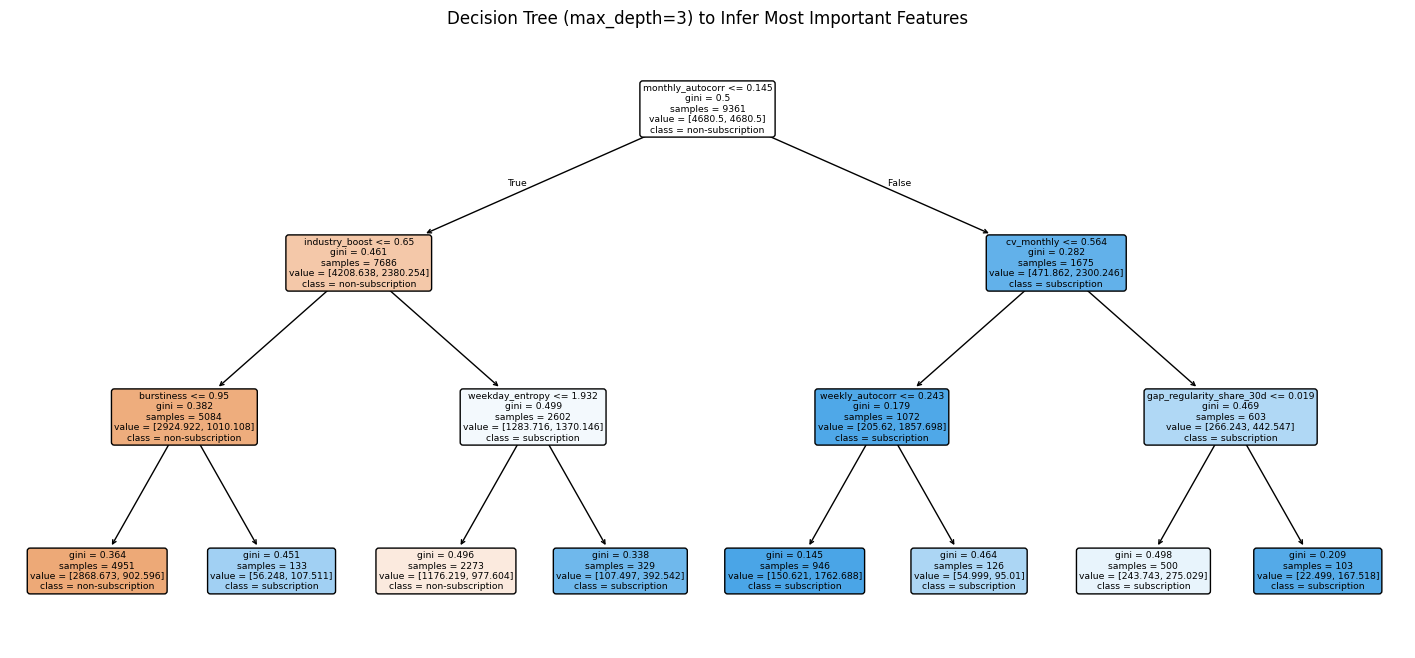

Accuracy test:  0.8051333167206579 Accuracy train:  0.8110244631983763
Feature importances (descending):
Feature monthly_autocorr: Importance = 0.6338
Feature industry_boost: Importance = 0.1580
Feature weekday_entropy: Importance = 0.0658
Feature cv_monthly: Importance = 0.0595
Feature burstiness: Importance = 0.0404
Feature gap_regularity_share_30d: Importance = 0.0254
Feature weekly_autocorr: Importance = 0.0171
Feature similarity_to_good: Importance = 0.0000
Feature biweekly_autocorr: Importance = 0.0000
Feature avg_gap_between_payments: Importance = 0.0000
Feature gap_regularity_share_7d: Importance = 0.0000
Feature cv_volume: Importance = 0.0000
Feature gaps_std: Importance = 0.0000
Feature payment_link_ratio: Importance = 0.0000
Feature cv_weekly: Importance = 0.0000
Feature volume_scale: Importance = 0.0000
Feature total_volume: Importance = 0.0000
Feature checkout_ratio: Importance = 0.0000
Feature active_ratio: Importance = 0.0000


In [26]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

# Train a decision tree classifier on the training data
dtree = DecisionTreeClassifier(max_depth=3, random_state=None, class_weight='balanced')
dtree.fit(x_train, y_train)

# Plot the decision tree to visualize feature importance and splits
features_name = feature_extracted.drop(columns=excludede_columns).columns.tolist()
plt.figure(figsize=(18, 8))
plot_tree(dtree, 
          feature_names=features_name, 
          class_names=[str(c) for c in dtree.classes_], 
          filled=True, 

          rounded=True)
plt.title("Decision Tree (max_depth=3) to Infer Most Important Features")
plt.show()

pred = dtree.predict(x_test)
accuracy_test, accuracy_train = dtree.score(x_test, y_test), dtree.score(x_train, y_train)
print('Accuracy test: ',accuracy_test, 'Accuracy train: ',accuracy_train)
# Print feature importances
importances = dtree.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
print("Feature importances (descending):")
for idx in sorted_indices:
    print(f"Feature {features_name[idx]}: Importance = {importances[idx]:.4f}")

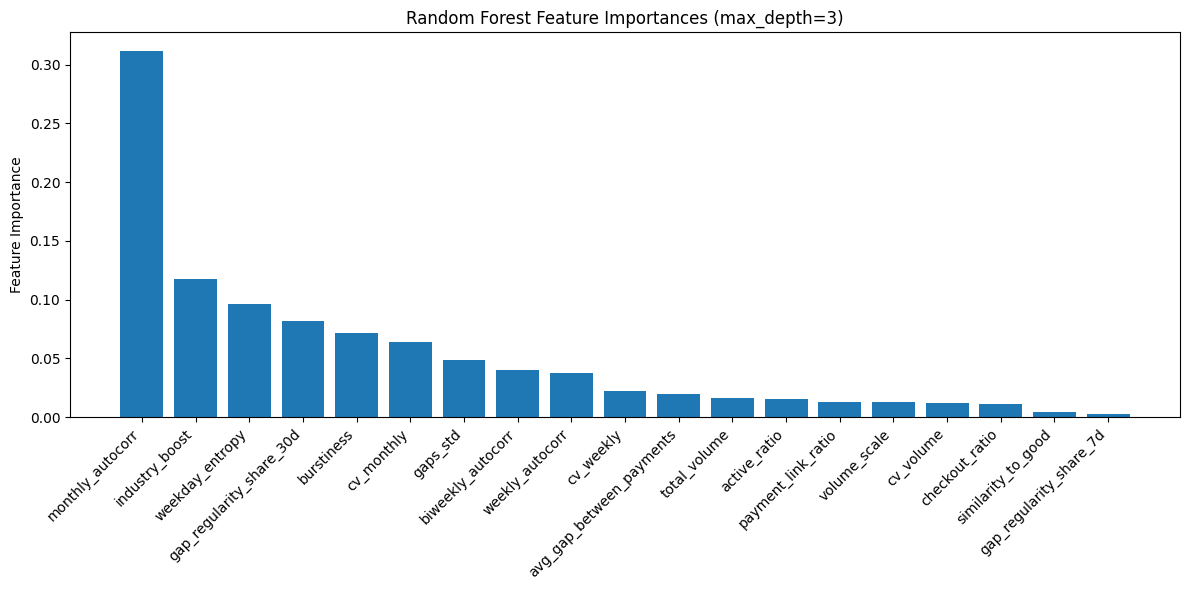

Accuracy test:  0.8377772240219288 Accuracy train:  0.8432859737207563
Feature importances (descending):
Feature monthly_autocorr: Importance = 0.3119
Feature industry_boost: Importance = 0.1173
Feature weekday_entropy: Importance = 0.0961
Feature gap_regularity_share_30d: Importance = 0.0823
Feature burstiness: Importance = 0.0720
Feature cv_monthly: Importance = 0.0643
Feature gaps_std: Importance = 0.0486
Feature biweekly_autocorr: Importance = 0.0401
Feature weekly_autocorr: Importance = 0.0376
Feature cv_weekly: Importance = 0.0223
Feature avg_gap_between_payments: Importance = 0.0198
Feature total_volume: Importance = 0.0166
Feature active_ratio: Importance = 0.0159
Feature payment_link_ratio: Importance = 0.0130
Feature volume_scale: Importance = 0.0126
Feature cv_volume: Importance = 0.0119
Feature checkout_ratio: Importance = 0.0112
Feature similarity_to_good: Importance = 0.0042
Feature gap_regularity_share_7d: Importance = 0.0024


In [80]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Train a random forest classifier on the training data
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=None, class_weight='balanced')
rf.fit(x_train, y_train)

# Feature names for plotting/importances
features_name = feature_extracted.drop(columns=excludede_columns).columns.tolist()

# Plot feature importances
importances = rf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(features_name)), importances[sorted_indices], align='center')
plt.xticks(range(len(features_name)), [features_name[i] for i in sorted_indices], rotation=45, ha='right')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances (max_depth=3)')
plt.tight_layout()
plt.savefig('random_forest_feature_importances.pdf')
plt.show()

# Predict and print accuracies
pred = rf.predict(x_test )
accuracy_test = rf.score(x_test, y_test)
accuracy_train = rf.score(x_train, y_train)
print('Accuracy test: ', accuracy_test, 'Accuracy train: ', accuracy_train)

# Print feature importances sorted
print("Feature importances (descending):")
for idx in sorted_indices:
    print(f"Feature {features_name[idx]}: Importance = {importances[idx]:.4f}")

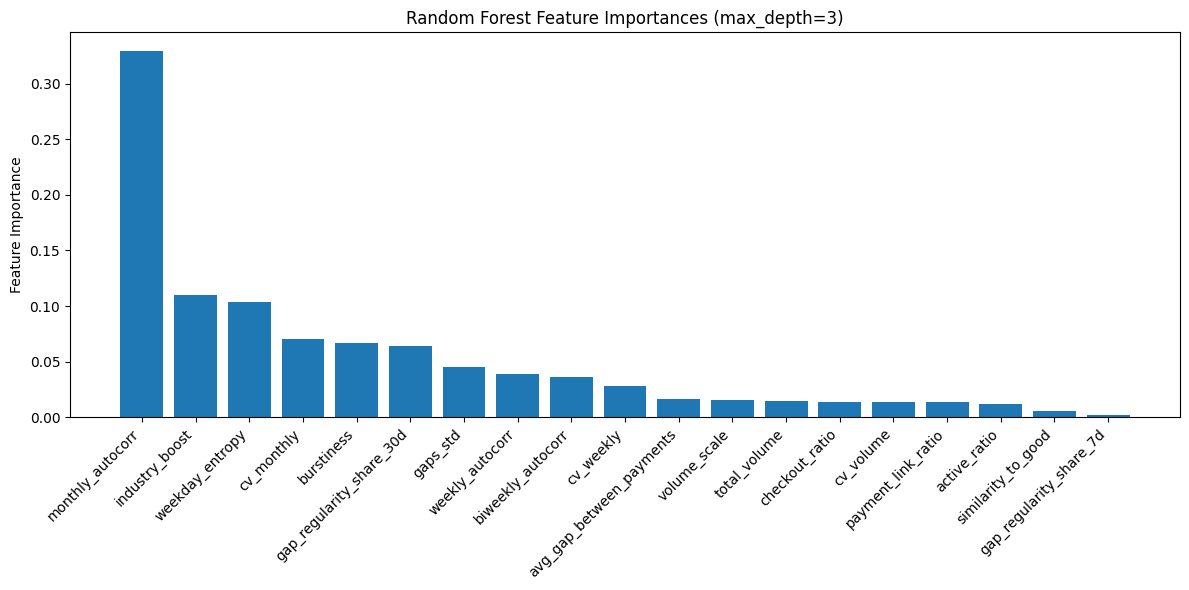

Accuracy test:  0.7597807126837777 Accuracy train:  0.7674393761350283
Feature importances (descending):
Feature monthly_autocorr: Importance = 0.3296
Feature industry_boost: Importance = 0.1100
Feature weekday_entropy: Importance = 0.1038
Feature cv_monthly: Importance = 0.0702
Feature burstiness: Importance = 0.0665
Feature gap_regularity_share_30d: Importance = 0.0642
Feature gaps_std: Importance = 0.0453
Feature weekly_autocorr: Importance = 0.0392
Feature biweekly_autocorr: Importance = 0.0359
Feature cv_weekly: Importance = 0.0277
Feature avg_gap_between_payments: Importance = 0.0164
Feature volume_scale: Importance = 0.0153
Feature total_volume: Importance = 0.0142
Feature checkout_ratio: Importance = 0.0142
Feature cv_volume: Importance = 0.0139
Feature payment_link_ratio: Importance = 0.0138
Feature active_ratio: Importance = 0.0120
Feature similarity_to_good: Importance = 0.0053
Feature gap_regularity_share_7d: Importance = 0.0023


In [101]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Train a random forest classifier on the training data
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=None, class_weight={'subscription':6, 'non-subscription':1})
rf.fit(x_train, y_train)

# Feature names for plotting/importances
features_name = feature_extracted.drop(columns=excludede_columns).columns.tolist()

# Plot feature importances
importances = rf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(features_name)), importances[sorted_indices], align='center')
plt.xticks(range(len(features_name)), [features_name[i] for i in sorted_indices], rotation=45, ha='right')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances (max_depth=3)')
plt.tight_layout()
plt.savefig('random_forest_feature_importances.pdf')
plt.show()

# Predict and print accuracies
pred = rf.predict(x_test )
accuracy_test = rf.score(x_test, y_test)
accuracy_train = rf.score(x_train, y_train)
print('Accuracy test: ', accuracy_test, 'Accuracy train: ', accuracy_train)

# Print feature importances sorted
print("Feature importances (descending):")
for idx in sorted_indices:
    print(f"Feature {features_name[idx]}: Importance = {importances[idx]:.4f}")

<Figure size 600x600 with 0 Axes>

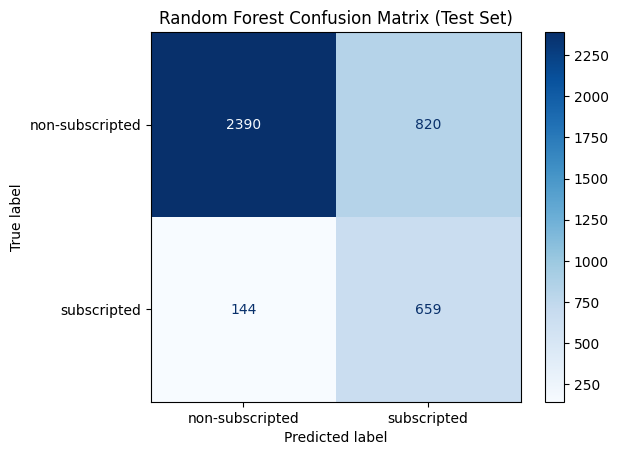

Classification Report (Test Set):
                  precision    recall  f1-score   support

non-subscription      0.943     0.745     0.832      3210
    subscription      0.446     0.821     0.578       803

        accuracy                          0.760      4013
       macro avg      0.694     0.783     0.705      4013
    weighted avg      0.844     0.760     0.781      4013



In [102]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predict the classes on the test set
y_pred_rf = rf.predict(x_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix
# Define the display labels as requested
labels = [ 'non-subscripted', 'subscripted']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Random Forest Confusion Matrix (Test Set)')
plt.savefig('random_forest_confusion_matrix.pdf')
plt.show()
from sklearn.metrics import classification_report

# Generate and display the classification report for the Random Forest classifier
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_rf, digits=3))

# who should we target? 

In [109]:
# beacuase they they seems to be unfamiliar with the subscription model
merchants_to_target = feature_extracted[feature_extracted['subscription_ratio'] < 0.2].reset_index().rename(columns={'index':'merchant'})['merchant'].tolist()
m_target = []
x_target = []
for m in merchants_to_target:
    # f = feature_extracted.loc[m].values[:12].tolist()
    f = feature_extracted.loc[m].drop(excludede_columns).values.tolist()
    f = np.abs(np.nan_to_num(f, nan=0))
    idx = merchant_id_list.index(m)
    m_target.append(m)
    # x_subscripted_feature.append(np.concatenate([time_series_pca[idx], f]))
    x_target.append(f)



confidences = rf.predict_proba(np.array(x_target))[:, 1]  # Probability for class 1 (subscripted)
# Let's associate each merchant with its confidence score
merchant_confidence = list(zip(m_target, confidences))
# Print or display sorted by confidence descending
merchant_confidence_sorted = sorted(merchant_confidence, key=lambda x: x[1], reverse=True)
for merchant, conf in merchant_confidence_sorted:
    print(f"Merchant: {merchant}, Confidence (subscripted): {conf:.4f}")



    

Merchant: aecc0ac2, Confidence (subscripted): 0.9676
Merchant: c956b53b, Confidence (subscripted): 0.9655
Merchant: bec9521b, Confidence (subscripted): 0.9651
Merchant: b051a58b, Confidence (subscripted): 0.9634
Merchant: 2496aa67, Confidence (subscripted): 0.9613
Merchant: c85d52c1, Confidence (subscripted): 0.9588
Merchant: f078f71c, Confidence (subscripted): 0.9570
Merchant: 240967ad, Confidence (subscripted): 0.9570
Merchant: a1ed1a8b, Confidence (subscripted): 0.9530
Merchant: 82c3ade0, Confidence (subscripted): 0.9507
Merchant: ea15635a, Confidence (subscripted): 0.9475
Merchant: f7db6c74, Confidence (subscripted): 0.9463
Merchant: 6eeffea7, Confidence (subscripted): 0.9456
Merchant: 6a03e3c2, Confidence (subscripted): 0.9448
Merchant: eb69b5c5, Confidence (subscripted): 0.9444
Merchant: 8f045ccd, Confidence (subscripted): 0.9440
Merchant: 47853c4b, Confidence (subscripted): 0.9434
Merchant: 44087b8d, Confidence (subscripted): 0.9413
Merchant: 883cb097, Confidence (subscripted): 

In [112]:
target_merchants = feature_extracted[feature_extracted['subscription_ratio'] < 0.2]
target_merchants = target_merchants.fillna(0)
# Apply np.abs only to numeric columns to avoid TypeError with string columns
numeric_cols = target_merchants.select_dtypes(include=[np.number]).columns
target_merchants[numeric_cols] = np.abs(target_merchants[numeric_cols])
_, counts =  np.unique(rf.predict(target_merchants.drop(columns=excludede_columns)), return_counts=True) 
total_merchants = np.sum(counts)
convertible_merchants = counts[1] if len(counts) > 1 else 0
print(f"Out of {total_merchants:,} merchants who are not currently using a subscription model, we predict that {convertible_merchants:,} could potentially be converted to a subscription-based approach.")

confidence_scores = rf.predict_proba(target_merchants.drop(columns=excludede_columns))[:, 1]

# Create a DataFrame for better visualization
confidence_df = pd.DataFrame({
    'Merchant': target_merchants.index.tolist(),
    'Confidence': confidence_scores,
    'volume_scale': target_merchants['volume_scale']/10
})

# # Sort by confidence descending
confidence_df = confidence_df.sort_values(by='Confidence', ascending=False)
confidence_df



# # Weighted score: adjust weights if business logic dictates different emphasis
confidence_df['ConfidenceWithVolume'] = (
    0.8 * confidence_df['Confidence'] +
    0.2 * confidence_df['volume_scale']
)

# # Sort by the new score
confidence_with_volume_sorted = confidence_df.sort_values(by='ConfidenceWithVolume', ascending=False)



num_high_conf = (confidence_with_volume_sorted['Confidence'] > 0.7).sum()
print(f"Number of merchants with >70% confidence (Confidence > 0.7): {num_high_conf:,}")


# Calculate and print additional conversion prediction metrics
num_medium_conf = ((confidence_with_volume_sorted['Confidence'] > 0.5) & 
                   (confidence_with_volume_sorted['Confidence'] <= 0.7)).sum()
num_low_conf = (confidence_with_volume_sorted['Confidence'] <= 0.5).sum()

print(f"Number of merchants with 50%-70% confidence (0.5 < Confidence <= 0.7): {num_medium_conf:,}")
print(f"Number of merchants with <=50% confidence (Confidence <= 0.5): {num_low_conf:,}")


confidence_with_volume_sorted.head(10)


/Users/alirezakeshavarzian/ThesisProject/STRIP/myenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/alirezakeshavarzian/ThesisProject/STRIP/myenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Out of 19,979 merchants who are not currently using a subscription model, we predict that 5,156 could potentially be converted to a subscription-based approach.
Number of merchants with >70% confidence (Confidence > 0.7): 878
Number of merchants with 50%-70% confidence (0.5 < Confidence <= 0.7): 4,278
Number of merchants with <=50% confidence (Confidence <= 0.5): 14,823


,Merchant,Confidence,volume_scale,ConfidenceWithVolume
3be20198,3be20198,0.904647,0.992699,0.922257
05d97088,05d97088,0.901332,1.000000,0.921066
4f4669ad,4f4669ad,0.900794,1.000000,0.920636
15f61630,15f61630,0.899342,1.000000,0.919474
740079ae,740079ae,0.896308,1.000000,0.917047
0ce8edbf,0ce8edbf,0.909836,0.938860,0.915641
64eda476,64eda476,0.910434,0.934805,0.915308
0480e56c,0480e56c,0.936712,0.815568,0.912483
34ecbf97,34ecbf97,0.890163,1.000000,0.912131
77fff849,77fff849,0.912823,0.905530,0.911365


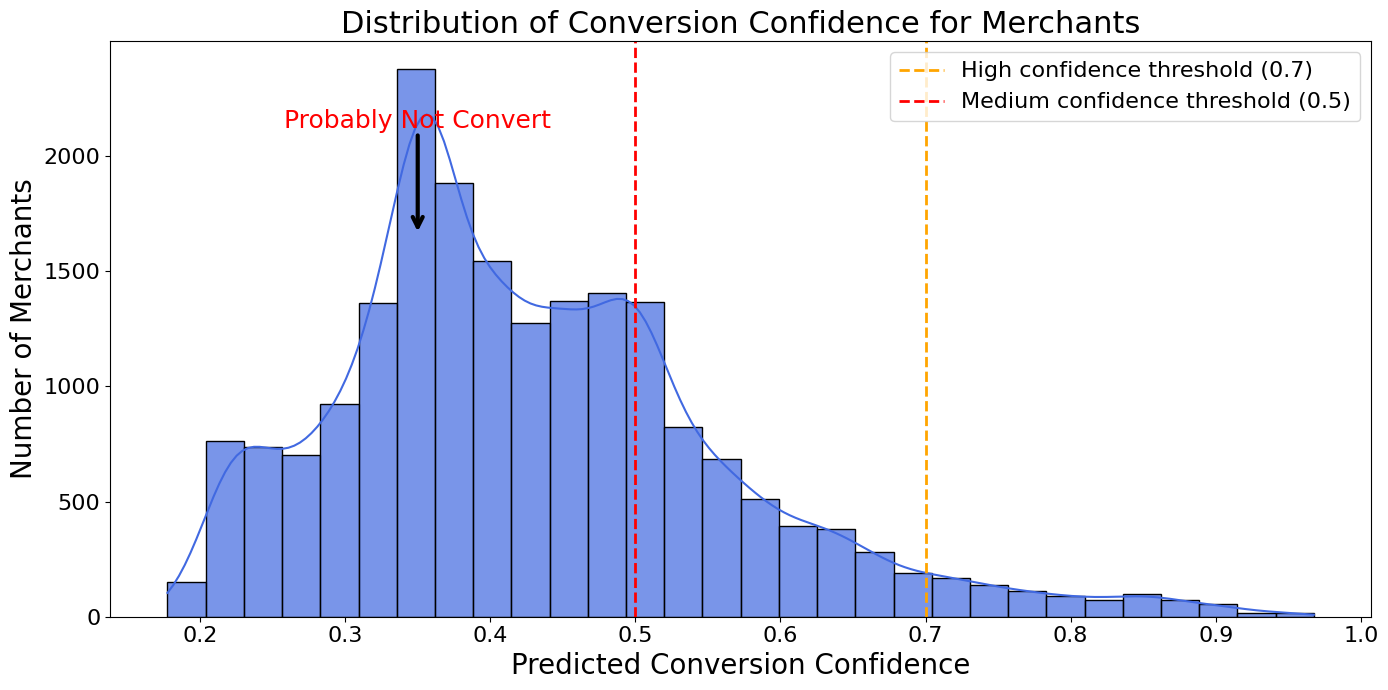

In [105]:
import matplotlib.pyplot as plt

import seaborn as sns

plt.figure(figsize=(14, 7))
sns.histplot(
    confidence_with_volume_sorted['Confidence'], 
    bins=30, 
    kde=True, 
    color='royalblue', 
    alpha=0.7
)

plt.axvline(0.7, color='orange', linestyle='--', linewidth=2, label='High confidence threshold (0.7)')
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Medium confidence threshold (0.5)')

# Place arrow and text in the area spanning 0.0 to 0.5
midpoint = 0.35
y_max = plt.gca().get_ylim()[1]
plt.annotate(
    'Probably Not Convert', 
    xy=(midpoint, y_max*0.65), 
    xytext=(midpoint, y_max*0.85),
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=3, shrinkA=0, shrinkB=8),
    fontsize=18, 
    color='red',
    horizontalalignment='center'
)

plt.title('Distribution of Conversion Confidence for Merchants', fontsize=22)
plt.xlabel('Predicted Conversion Confidence', fontsize=20)
plt.ylabel('Number of Merchants', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('confidence_distribution.pdf')
plt.show()

